# Projet d'analyse de données :  Analyse des matches de la Premier league (2017/2018)
Cheikh TOURE & Ahmed BOUREIMA, 3A MAM,S5,Polytech Lyon 2025/2026

## **Introduction**
Dans ce projet, nous analysons un jeu de données contenant les matchs de la 1ere division de football d’Angleterre lors de la saison 2017\2018.
Ces données incluent les équipes participantes, les scores, le vainqueur du match ainsi que l’information domicile ou extérieur entre autres.

L’objectif de cette étude est de comprendre les performances des équipes à travers différents indicateurs, comme le nombre de buts marqués et encaissés, l’impact du facteur domicile et la capacité à gagner à l’extérieur.
Grâce à des analyses statistiques et des visualisations, nous mettons en évidence les tendances majeures du championnat et les équipes les plus performantes.

Cette analyse constitue également une base pour une approche de modélisation, permettant d’expliquer et d’anticiper les résultats des matchs à partir des données observées.
Nous essayerons de répondre à la problématique suivante: Quels facteurs expliquent le plus la victoire ?



---



## I -**Collecte et structuration des données**

## Importation des bibliotheques necessaires

dans un premier temps nous allons importer les librairies dont nous avons besoins pour les calculs

**Pandas as pd** Utilisé pour la manipulation et l'analyse de données

**numpy as np**: Fournit un support pour les tableaux et matrices, ainsi que des fonctions mathématiques de haut niveau pour opérer sur ces tableaux

**matplotlib.pyplot as plt**: Une bibliothèque de traçage complète pour créer des visualisations statiques, animées et interactives en PythoN


**seaborn as sns**: Basé sur Matplotlib, Seaborn fournit une interface de haut niveau pour dessiner des graphiques statistiques attrayants et informatifS

**plotly.express as px**: Une bibliothèque Python de haut niveau qui permet de créer des figures Plotly complètes avec seulement quelques lignes de code.

**plotly.graph_objects as go**: Fournit une interface plus granulaire pour créer des figures Plotly, permettant un contrôle plus fin des éléments graphiques


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

Ensemble, ces bibliothèques forment une boîte à outils puissante pour l'exploration, la transformation et la présentation visuelle des données dans un projet d'analyse.



## Notre jeu de données
Nous avons utilisés 4 bases de données   disponibles  sur le site figshare.com : une pour les matches ,une pour les équipes , une pour les joueurs et une autre pour les evenements du match.
pour la base de données des équipes et des joueurs, on les a juste utilisé pour récuperer les noms des clubs et des joueurs.Mais notre principale jeu de données est le dataset Matches_England.json .

**matches_England** : contient  les informations sur les match
elle comprend
380 lignes → chaque ligne correspond à un match

16 colonnes → chaque colonne décrit une caractéristique du match

**teams(1)** concernant les informations sur les equipes


**players** concernant les informations sur les joueurs



In [ ]:
df = pd.read_json("//matches_England.json")
teams_df= pd.read_json("/teams(1).json")
players_df = pd.read_json("/players.json")
events_df = pd.read_json("/events_England.json")

description des jeux de données:


Cet ensemble de données décrit tous les matchs mis à disposition. Chaque match est un document composé des champs suivants:

- **competitionId** : l'identifiant de la compétition à laquelle appartient le match. Il s'agit d'un nombre entier et fait référence au champ "wyId" du competitiondocument de concours;
- **date** et **dateutc** : le premier spécifie la date et l'heure où le match commence au format explicite (par exemple, 20 mai 2018 à 8:45:00 PM GMT+2), le second contient les mêmes informations mais au format compact YYYY-MM-DD hh:mm:ss;
- **duration** : la durée du match. Il peut être "regular" (matchs de durée régulière de 90 minutes + temps d'arrêt), "ExtraTime" (matchs avec des temps supplémentaires, comme cela peut se produire pour les matchs dans les compétitions continentales ou internationales), ou "Pénalités" (matchs qui se terminent par des coups de pied de pénalité, comme cela peut se produire pour les compétitions continentales ou internationales);
- **gameweek** : la semaine de la ligue, à partir du début de la ligue;
- **label** : contient le nom des deux clubs et le résultat du match (par exemple, "Lazio - Internazionale, 2 - 3");
- **roundId** : indique le jour de match de la compétition à laquelle appartient le match. Lors d'une compétition pour les clubs de football, chacun des clubs participants joue contre chacun des autres clubs deux fois, une fois à la maison et une fois à l'extérieur. Les matchs sont organisés en jours de match: tous les matchs en journée de match sont joués avant les matchs dans la journée de match i + 1, même difficile certains matchs peuvent être anticipés ou reportés pour faciliter les joueurs et les clubs participant aux compétitions continentales ou intercontinentales. Lors d'une compétition pour les équipes nationales, le "roundID" indique l'étape de la compétition (tour d'élimination, tour de 16 quarts de finale, demi-finales, finale);
- **saisonId** : indique la saison du match ;
- **status**: il peut être "Joué" (le match a officiellement terminé), "Annulé" (le match a été annulé pour une raison quelconque), "Reporté" (le match a été reporté et aucune nouvelle date et heure n'est encore disponible) ou "Suspendu" (le match a été suspendu et aucune nouvelle date et heure n'est encore disponible);
- **venue** : le stade où le match a eu lieu (par exemple, "Stadio Olimpico");
- **winner** : l'identifiant de l'équipe qui a gagné la partie, ou 0 si le match se termine par un match nul;
- **wyId** : l'identifiant de la correspondance, attribué par Wyscout;
- **teamsData** : il contient plusieurs sous-champs décrivant des informations sur chaque équipe qui joue ce match: tels que l'alignement, la composition du banc, la liste des substitutions, l'entraîneur et les scores:
- **hasFormation** : il a valeur 0 si aucune formation (alignements et bancs) n'est présente, et 1 sinon;
- **score** : le nombre de buts marqués par l’équipe pendant le match (sans compter les pénalités) ;
- **scoreET** : le nombre de buts marqués par l’équipe pendant le match, y compris le temps supplémentaire (sans compter les pénalités) ;
- **scoreHT** : le nombre de buts marqués par l’équipe durant la première moitié du match ;
- **scoreP** : le nombre total de buts marqués par l’équipe après les pénalités ;
- **side** : le côté équipe dans le match (il peut être "à la maison" ou "l'extérieur");
- **teamId** : l’identifiant de l’équipe ;
- **coachId** : l'identifiant du coach de l'équipe ;
- **bench** : la liste des joueurs de l'équipe qui ont commencé le match dans le banc et quelques statistiques de base sur leur performance pendant le match (buts, buts, cartes);
- **lineup** : la liste des joueurs de l'équipe dans la formation de départ et quelques statistiques de base sur leur performance pendant le match (buts, buts, cartes);
- **substitutions** : la liste des substitutions de l'équipe pendant le match, décrivant les joueurs impliqués et la minute de la substitution.

Observation des contenus des jeux de données.

In [ ]:
df.head()

,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4405654,38,"{'1646': {'scoreET': 0, 'coachId': 8880, 'side...",181150,2018-05-13 14:00:00,1659,Turf Moor,2500089,"Burnley - AFC Bournemouth, 1 - 2","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 385705, 'role': 'referee'}, {'r...",Regular,364
1,Played,4405654,38,"{'1628': {'scoreET': 0, 'coachId': 8357, 'side...",181150,2018-05-13 14:00:00,1628,Selhurst Park,2500090,"Crystal Palace - West Bromwich Albion, 2 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 381851, 'role': 'referee'}, {'r...",Regular,364
2,Played,4405654,38,"{'1609': {'scoreET': 0, 'coachId': 7845, 'side...",181150,2018-05-13 14:00:00,1609,The John Smith's Stadium,2500091,"Huddersfield Town - Arsenal, 0 - 1","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 384965, 'role': 'referee'}, {'r...",Regular,364
3,Played,4405654,38,"{'1651': {'scoreET': 0, 'coachId': 8093, 'side...",181150,2018-05-13 14:00:00,1612,Anfield,2500092,"Liverpool - Brighton & Hove Albion, 4 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 385704, 'role': 'referee'}, {'r...",Regular,364
4,Played,4405654,38,"{'1644': {'scoreET': 0, 'coachId': 93112, 'sid...",181150,2018-05-13 14:00:00,1611,Old Trafford,2500093,"Manchester United - Watford, 1 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 381853, 'role': 'referee'}, {'r...",Regular,364


In [ ]:
events_df.head()

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175


In [ ]:
teams_df.head()

,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alav\u00e9s,696,Deportivo Alav\u00e9s,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club


In [ ]:
players_df.head()

,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null
3,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",82,Alfred John Momar,,N'Diaye,683,1990-03-06,187,"{'code2': 'MD', 'code3': 'MID', 'name': 'Midfi...","{'name': 'France', 'id': '250', 'alpha3code': ...",32793,right,A. N'Diaye,19314
4,"{'name': 'France', 'id': '250', 'alpha3code': ...",84,Ibrahima,,Konat\u00e9,2975,1999-05-25,192,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393247,right,I. Konat\u00e9,null


Pour une meilleure lisibilité du dataset ainsi qu'une meilleure exploitation,nous allons associer  les noms des équipes (jouant à l'exterieur ou à domicile )à leurs identifiants attribués par Wyscout (le logiciel permettant aux professionnels du foot d'accéder à des données détaillées sur les performances physiques et techniques des joueurs) ainsi que les noms des joueurs à leurs identifiants.



In [ ]:
team_map = dict(zip(teams_df["wyId"], teams_df["officialName"])) #pour associer chaque identifiant au nom de l'equipe
player_map = dict(zip(players_df["wyId"], players_df["shortName"])) #pour associer chaque identifiant au joueur correspondant
#test
team_map[df["winner"][1]] #gagnant du match 2



'Crystal Palace FC'

## Suppression des variables inutiles

Nous allons supprimés les variables qui ne nous seront pas utlile pour notre projet car ces derniers n'apporte pas assez d'informations pertinantes à notre avis.

In [ ]:
df.columns

Index(['status', 'roundId', 'gameweek', 'teamsData', 'seasonId', 'dateutc',
       'winner', 'venue', 'wyId', 'label', 'date', 'referees', 'duration',
       'competitionId'],
      dtype='object')

In [ ]:
df = df.drop(columns=["status","seasonId","date","duration","roundId","competitionId"])

In [ ]:
df.head()

,gameweek,teamsData,dateutc,winner,venue,wyId,label,referees
0,38,"{'1646': {'scoreET': 0, 'coachId': 8880, 'side...",2018-05-13 14:00:00,1659,Turf Moor,2500089,"Burnley - AFC Bournemouth, 1 - 2","[{'refereeId': 385705, 'role': 'referee'}, {'r..."
1,38,"{'1628': {'scoreET': 0, 'coachId': 8357, 'side...",2018-05-13 14:00:00,1628,Selhurst Park,2500090,"Crystal Palace - West Bromwich Albion, 2 - 0","[{'refereeId': 381851, 'role': 'referee'}, {'r..."
2,38,"{'1609': {'scoreET': 0, 'coachId': 7845, 'side...",2018-05-13 14:00:00,1609,The John Smith's Stadium,2500091,"Huddersfield Town - Arsenal, 0 - 1","[{'refereeId': 384965, 'role': 'referee'}, {'r..."
3,38,"{'1651': {'scoreET': 0, 'coachId': 8093, 'side...",2018-05-13 14:00:00,1612,Anfield,2500092,"Liverpool - Brighton & Hove Albion, 4 - 0","[{'refereeId': 385704, 'role': 'referee'}, {'r..."
4,38,"{'1644': {'scoreET': 0, 'coachId': 93112, 'sid...",2018-05-13 14:00:00,1611,Old Trafford,2500093,"Manchester United - Watford, 1 - 0","[{'refereeId': 381853, 'role': 'referee'}, {'r..."




---



## **II -Analyse exploratoire et Visualisation**

## **A -Analyse simple**

**Nombre de victoires à domicile vs à l’extérieur**

type_victoire
Domicile     171
Extérieur    108
Name: count, dtype: int64


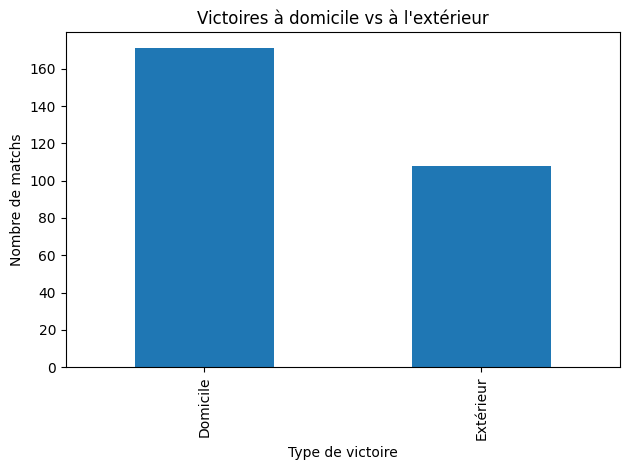

In [ ]:

# Créer une liste pour stocker le type de victoire

victoires = []

#Parcourir chaque match (chaque ligne du DataFrame)

for _, row in df.iterrows():

    winner = row["winner"]        # équipe gagnante du match
    teams = row["teamsData"]     # (home / away)

    #Parcourir les équipes du match
    for team_id, info in teams.items():

        # Si cette équipe est la gagnante
        if info["teamId"] == winner:

            # Vérifier si elle joue à domicile ou à l'extérieur
            if info["side"] == "home":
                victoires.append("Domicile")
            else:
                victoires.append("Extérieur")


# 5) Transformer la liste en DataFrame
df_victoires = pd.DataFrame({"type_victoire": victoires})


# 6) Compter le nombre de victoires
resultats = df_victoires["type_victoire"].value_counts()

print(resultats)

# 7) Faire le graphique

plt.figure()
resultats.plot(kind="bar")
plt.title("Victoires à domicile vs à l'extérieur")
plt.xlabel("Type de victoire")
plt.ylabel("Nombre de matchs")
plt.tight_layout()
plt.show()


On observe que les victoires à domicile sont plus nombreuses que les victoires à l’extérieur.
Cela confirme l’existence d’un avantage du terrain :

* les équipes jouent devant leur public,

* elles connaissent mieux leur stade,

* elles subissent moins la fatigue des déplacements.

 jouer à domicile augmente la probabilité de gagner un match.

**moyenne de buts domicile vs extérieur**

**classement des équipes par buts marqués**

side
away    1.147368
home    1.531579
Name: score, dtype: float64


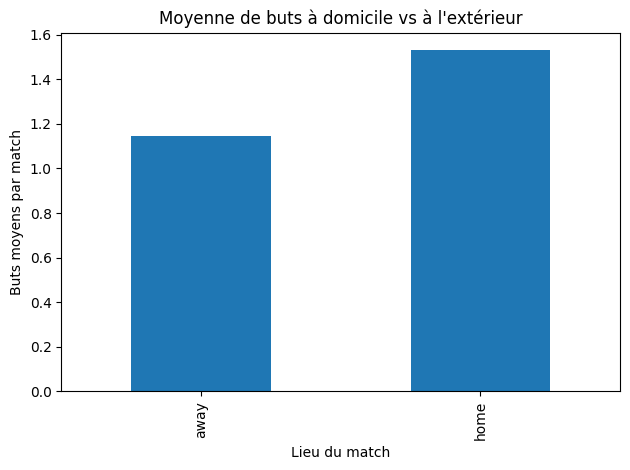

In [ ]:
#Créer une liste pour stocker les buts
# =========================
buts = []


# Parcourir chaque match
for _, row in df.iterrows():

    teams = row["teamsData"]   # données  (home / away)

    # Parcourir chaque équipe du match
    for team_id, info in teams.items():

        buts.append({
            "side": info["side"],      # home ou away
            "score": info["score"]     # nombre de buts
        })


# Transformer en DataFrame
df_buts = pd.DataFrame(buts)

#  Calculer la moyenne de buts par type (domicile / extérieur)
moyenne_buts = df_buts.groupby("side")["score"].mean()

print(moyenne_buts)

# Faire un graphique
plt.figure()
moyenne_buts.plot(kind="bar")
plt.title("Moyenne de buts à domicile vs à l'extérieur")
plt.xlabel("Lieu du match")
plt.ylabel("Buts moyens par match")
plt.tight_layout()
plt.show()



Les équipes marquent en moyenne plus de buts à domicile qu’à l’extérieur.
Cela peut s’expliquer par :

un style de jeu plus offensif à domicile,

le soutien du public

In [ ]:


#Extraire les buts de chaque équipe depuis teamsData
buts_equipes = []

for _, row in df.iterrows():
    teams = row["teamsData"]

    for team_id, info in teams.items():
        buts_equipes.append({
            "teamId": info["teamId"],
            "buts": info["score"]
        })
# Transformer en DataFrame


df_buts = pd.DataFrame(buts_equipes)

# Calculer le total de buts par équipe
classement = (
    df_buts
    .groupby("teamId")["buts"]
    .sum()
    .reset_index()
    .sort_values(by="buts", ascending=False)
)
# Utiliser ton mapping pour ajouter le nom des équipes

classement["team_name"] = classement["teamId"].map(team_map)

# Afficher le classement final

print(classement[["team_name", "buts"]])


                    team_name  buts
8          Manchester City FC   106
3                Liverpool FC    84
7        Tottenham Hotspur FC    74
0                  Arsenal FC    74
2        Manchester United FC    68
1                  Chelsea FC    62
11          Leicester City FC    56
12         West Ham United FC    48
17            AFC Bournemouth    45
10          Crystal Palace FC    45
6                  Everton FC    44
14                 Watford FC    44
4         Newcastle United FC    39
5              Southampton FC    37
15                 Burnley FC    36
13              Stoke City FC    35
16  Brighton & Hove Albion FC    34
9     West Bromwich Albion FC    31
18       Huddersfield Town FC    28
19           Swansea City AFC    28


**TOP 10**

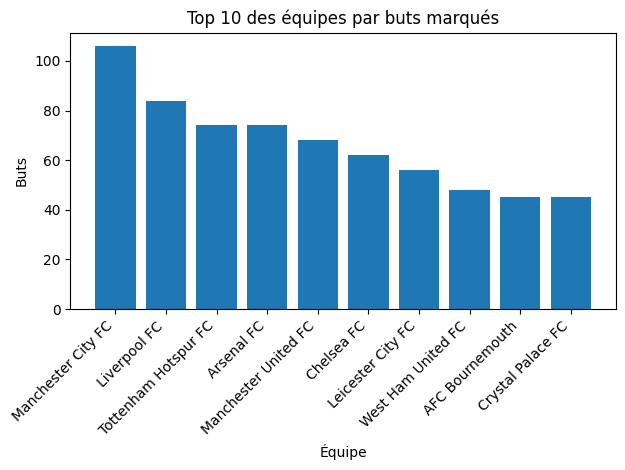

In [ ]:
import matplotlib.pyplot as plt

top10 = classement.head(10)

plt.figure()
plt.bar(top10["team_name"], top10["buts"])
plt.title("Top 10 des équipes par buts marqués")
plt.xlabel("Équipe")
plt.ylabel("Buts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Ce graphique classe les 10 équipes ayant marqué le plus de buts sur la saison.
Chaque barre représente le total de buts inscrits par une équipe.

**CLASSEMENT DES EQUIPES PAR BUTS ENCAISSES**

                    team_name  buts_encaisses
8          Manchester City FC              27
2        Manchester United FC              28
7        Tottenham Hotspur FC              36
3                Liverpool FC              38
1                  Chelsea FC              38
15                 Burnley FC              39
4         Newcastle United FC              47
0                  Arsenal FC              51
16  Brighton & Hove Albion FC              54
10          Crystal Palace FC              55
9     West Bromwich Albion FC              56
5              Southampton FC              56
19           Swansea City AFC              56
18       Huddersfield Town FC              58
6                  Everton FC              58
11          Leicester City FC              60
17            AFC Bournemouth              61
14                 Watford FC              64
12         West Ham United FC              68
13              Stoke City FC              68


Text(0, 0.5, 'Buts encaissés')

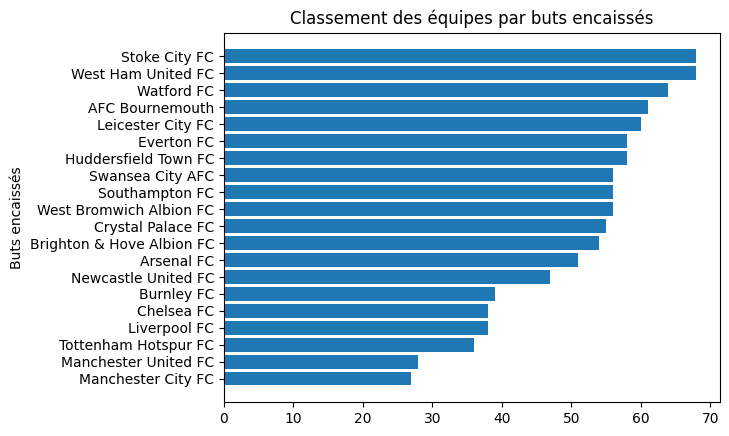

In [ ]:

# Créer une liste pour stocker les buts encaissés
buts_encaisses = []

# Parcourir chaque match
for _, row in df.iterrows():

    teams = row["teamsData"]

    #Récupérer les scores des deux équipes du match
    scores = [info["score"] for info in teams.values()]

    # Pour chaque équipe, les buts encaissés
    for team_id, info in teams.items():

        but_adversaire = sum(scores) - info["score"]

        buts_encaisses.append({
            "teamId": info["teamId"],
            "buts_encaisses": but_adversaire
        })

# Transformer en DataFrame
# =========================
df_encaisses = pd.DataFrame(buts_encaisses)

# Calculer le total de buts encaissés par équipe
classement_defense = (
    df_encaisses
    .groupby("teamId")["buts_encaisses"]
    .sum()
    .reset_index()
    .sort_values(by="buts_encaisses", ascending=True))


# Ajoutons le nom des équipes
classement_defense["team_name"] = classement_defense["teamId"].map(team_map)

# Affichons le classement final

print(classement_defense[["team_name", "buts_encaisses"]])
classement_defense_df = classement_defense[["team_name", "buts_encaisses"]]
plt.figure()
plt.barh(classement_defense_df["team_name"], classement_defense_df["buts_encaisses"])
plt.title("Classement des équipes par buts encaissés")
plt.ylabel("Buts encaissés")

ce classement présente les équipes en fonction du nombre total de buts encaissés sur la saison.
Les équipes en haut du classement sont celles ayant la meilleure solidité défensive.

**CLASSEMENT : ÉQUIPES QUI GAGNENT LE PLUS À DOMICILE**

                    team_name  victoires_domicile
0          Manchester City FC                  16
1        Manchester United FC                  15
2                  Arsenal FC                  15
3        Tottenham Hotspur FC                  13
4                Liverpool FC                  12
5                  Chelsea FC                  11
6                  Everton FC                   9
7         Newcastle United FC                   8
8           Crystal Palace FC                   7
9           Leicester City FC                   7
10            AFC Bournemouth                   7
11         West Ham United FC                   7
12                 Burnley FC                   7
13  Brighton & Hove Albion FC                   7
14                 Watford FC                   6
15       Huddersfield Town FC                   6
16           Swansea City AFC                   6
17              Stoke City FC                   5
18             Southampton FC                   4


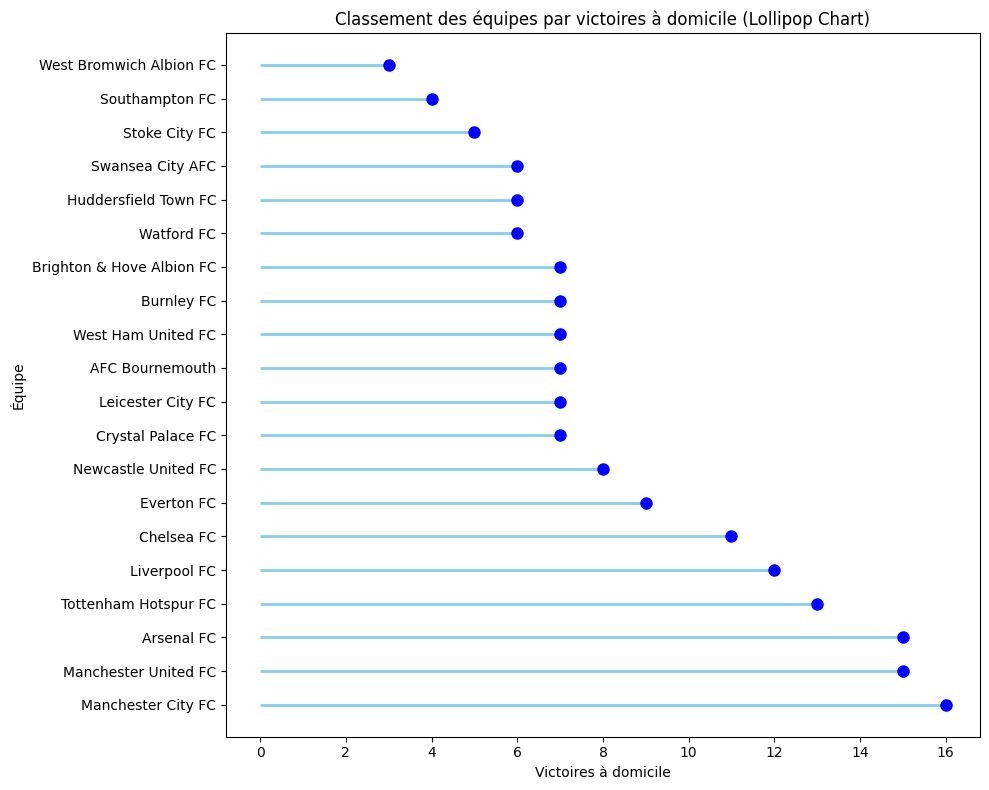

In [ ]:


#recuperons les victoires à domicile

data = []

for _, row in df.iterrows():
    winner = row["winner"]
    teams = row["teamsData"]

    for t in teams.values():
        # Si l'équipe est gagnante ET joue à domicile
        if t["teamId"] == winner and t["side"] == "home":
            data.append(t["teamId"])


df_home_wins = pd.DataFrame(data, columns=["teamId"])

# Compter les victoires par équipe + trier

classement_home = (
    df_home_wins["teamId"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "teamId", "count": "victoires_domicile"}) # Correction ici
)


classement_home["team_name"] = classement_home["teamId"].map(team_map)
print(classement_home[["team_name", "victoires_domicile"]])

classement_home_df = classement_home[["team_name", "victoires_domicile"]]

# Création du graphique en forme de 'lollipop'
plt.figure(figsize=(10, 8))
plt.hlines(y=classement_home_df["team_name"], xmin=0, xmax=classement_home_df["victoires_domicile"], color='skyblue', linewidth=2)
plt.plot(classement_home_df["victoires_domicile"], classement_home_df["team_name"], "o", markersize=8, color='blue')

plt.title("Classement des équipes par victoires à domicile (Lollipop Chart)")
plt.xlabel("Victoires à domicile")
plt.ylabel("Équipe")
plt.tight_layout()
plt.show()

Ce classement met en évidence les équipes qui tirent le meilleur avantage du facteur domicile.
Ces équipes :

gagnent plus souvent devant leur public,

imposent mieux leur jeu à la maison,

et sont souvent parmi les meilleures du championnat.

**CLASSEMENT : ÉQUIPES QUI GAGNENT LE PLUS À L’EXTÉRIEUR**

In [ ]:



# 1) Récupérer les victoires à l'extérieur

data = []

for _, row in df.iterrows():
    winner = row["winner"]
    teams = row["teamsData"]

    for t in teams.values():
        if t["teamId"] == winner and t["side"] == "away":
            data.append(t["teamId"])

#
df_away_wins = pd.DataFrame(data, columns=["teamId"])

classement_away = (
    df_away_wins["teamId"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "teamId", "count": "victoires_exterieur"}))


classement_away["team_name"] = classement_away["teamId"].map(team_map)

print(classement_away[["team_name", "victoires_exterieur"]])


                    team_name  victoires_exterieur
0          Manchester City FC                   16
1        Tottenham Hotspur FC                   10
2        Manchester United FC                   10
3                  Chelsea FC                   10
4                Liverpool FC                    9
5                  Burnley FC                    7
6           Leicester City FC                    5
7             AFC Bournemouth                    4
8                  Watford FC                    4
9                  Arsenal FC                    4
10        Newcastle United FC                    4
11          Crystal Palace FC                    4
12                 Everton FC                    3
13    West Bromwich Albion FC                    3
14         West Ham United FC                    3
15             Southampton FC                    3
16       Huddersfield Town FC                    3
17              Stoke City FC                    2
18           Swansea City AFC  

## B- **Analyse intermédiaire**

### **1.Comparaison de la dynamique des matchs**







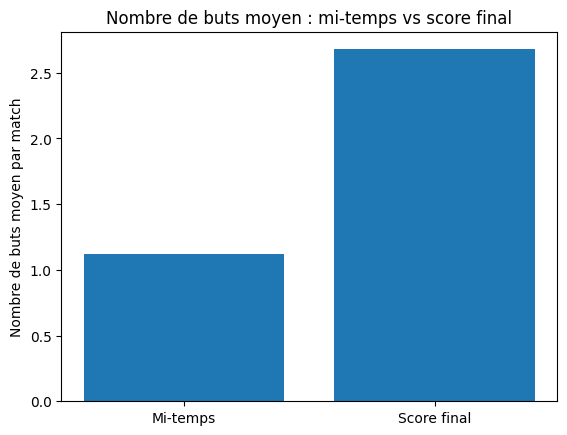

In [ ]:
#receuillons les buts inscrits à la 1ere mi temps et ceux inscrits dans la seconde mi-temps
buts_mi_temps = []
buts_final = []

for _, row in df.iterrows(): #pour chaque match
    teams = row["teamsData"]  #teams reçoit une observation pour la variable teamsData

    ht_total = 0
    ft_total = 0

    for team_id, team_data in teams.items(): #pour chaque équipe ,on recupere le scoreHT et le scoreFT
        ht_total += team_data["scoreHT"]
        ft_total += team_data["score"]

    buts_mi_temps.append(ht_total)
    buts_final.append(ft_total)

df_scores = pd.DataFrame({              # on cree un nouveau df pour y mettre ces données
    "buts_mi_temps": buts_mi_temps,
    "buts_final": buts_final
})

moyennes = [np.mean(buts_mi_temps), np.mean(buts_final)]
labels = ["Mi-temps", "Score final"]
plt.figure()
plt.bar(labels, moyennes)
plt.ylabel("Nombre de buts moyen par match")
plt.title("Nombre de buts moyen : mi-temps vs score final")
plt.show()



on voit que la majorité des buts sont marquées à la seconde période.Il ya en moyenne un but de plus en seconde mi-temps.Donc il y a certainement beaucoup de matchs qui ont été renversés à la mi-temps.Il est donc difficile de prévoir le résultat d'un match meme à la mi-temps.

Nombre de matchs renversés à la seconde période : 145


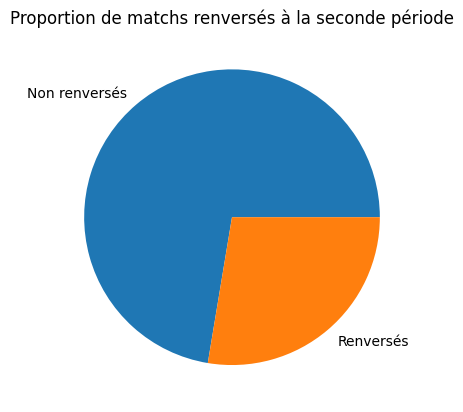

In [ ]:
matchs_renversés = 0
for _, row in df.iterrows():
    teams = row["teamsData"]

    #données equipes exterieures et domiciles
    home_team_data = {}
    away_team_data = {}
    for team_id, team_data in teams.items():
        if team_data['side'] == 'home':
            home_team_data = team_data
        else:
            away_team_data = team_data

    home_ht_score = home_team_data['scoreHT']
    away_ht_score = away_team_data['scoreHT']
    home_ft_score = home_team_data['score']
    away_ft_score = away_team_data['score']

    # resulat a la mi-temps
    ht_winner = None
    if home_ht_score > away_ht_score:
        ht_winner = 'home'
    elif away_ht_score > home_ht_score:
        ht_winner = 'away'
    else:
        ht_winner = 'draw'

    # resultat a la fin
    ft_winner = None
    if home_ft_score > away_ft_score:
        ft_winner = 'home'
    elif away_ft_score > home_ft_score:
        ft_winner = 'away'
    else:
        ft_winner = 'draw'

    # Verification des renversement:
    # Un reversement a lieu si une équipe perd le match apres avoir mené à la mi-temps
    # Ou si le score était nul à la mi-temps mais qu'une équipe gagne à la fin
    if ht_winner == 'home' and ft_winner != 'home':
        matchs_renversés += 1
    elif ht_winner == 'away' and ft_winner != 'away':
        matchs_renversés += 1
    elif ht_winner == 'draw' and ft_winner != 'draw':
        matchs_renversés += 1

print(f"Nombre de matchs renversés à la seconde période : {matchs_renversés}")

# Graphique en camembert des proportions
labels = ['Non renversés', 'Renversés']
valeurs = [380, matchs_renversés]
dictionary = {'valeurs':valeurs, 'labels':labels}
python_pie_chart_df = pd.DataFrame(dictionary)
plt.pie(x = python_pie_chart_df.valeurs, labels = python_pie_chart_df.labels)
plt.title("Proportion de matchs renversés à la seconde période")
plt.show()



---



### **2.Impact de la discipline dans un match**

Etudions l'impact des cartons recus sur l'issue des matchs en général.

Repartition des nombres de cartons entre les équipes.

In [ ]:
team_match_card_totals = [] #pour stocker les nombres de cartons par match

for _, row in df.iterrows(): # pour chaque match
    teams = row["teamsData"]
    for team_id_str, team_data in teams.items(): # pour chaque équipe
        team_id = int(team_id_str) # on convertie teamId en entier (il était en str de base)

        current_match_yellow_cards = 0
        current_match_red_cards = 0


        lineup = team_data["formation"].get("lineup", [])
        bench = team_data["formation"].get("bench", [])

        # Pour chaque joueur de l'équipe(titulaires et remplaçants) si la valeur pour yellow/red cards est !=0
        # Dans le jeu de données,yellowCards et redCards contiennent la minute ou le carton a été donné
        for player_data in lineup + bench:
            if player_data.get("yellowCards", '0') != '0':
                current_match_yellow_cards += 1

            if player_data.get("redCards", '0') != '0':
                current_match_red_cards += 1

        team_match_card_totals.append({
            "team_id": team_id,
            "match_yellow_cards": current_match_yellow_cards,
            "match_red_cards": current_match_red_cards
        })

# On met ces données dans un nouveau dataframe
team_match_cards_df = pd.DataFrame(team_match_card_totals)

# on utilise groupeby pour obtenir le nombre total de carton par équipe
team_season_total_cards = team_match_cards_df.groupby('team_id').agg({
    'match_yellow_cards': 'sum',
    'match_red_cards': 'sum'
}).reset_index()

# On renomme les colonnes pour plus de lisibilité
team_season_total_cards = team_season_total_cards.rename(columns={
    'match_yellow_cards': 'yellow_cards',
    'match_red_cards': 'red_cards'
})

# Merge avec teams_df pour avoir les noms des équipes
merged_team_season_totals = team_season_total_cards.merge(
    teams_df[['wyId', 'name']],
    left_on='team_id',
    right_on='wyId',
    how='left'
)
merged_team_season_totals = merged_team_season_totals.drop(columns=['wyId']) # on supprime la colonne redondante

display(merged_team_season_totals.sort_values(by=['yellow_cards', 'red_cards'], ascending=False))


,team_id,yellow_cards,red_cards,name
12,1633,74,2,West Ham United
9,1627,73,1,West Bromwich Albion
10,1628,72,0,Crystal Palace
15,1646,65,0,Burnley
14,1644,64,4,Watford
2,1611,64,1,Manchester United
18,1673,63,3,Huddersfield Town
5,1619,63,2,Southampton
13,1639,63,1,Stoke City
8,1625,61,2,Manchester City


Voyons ça sous la forme d'un graphique pour se faire une meilleure idée.

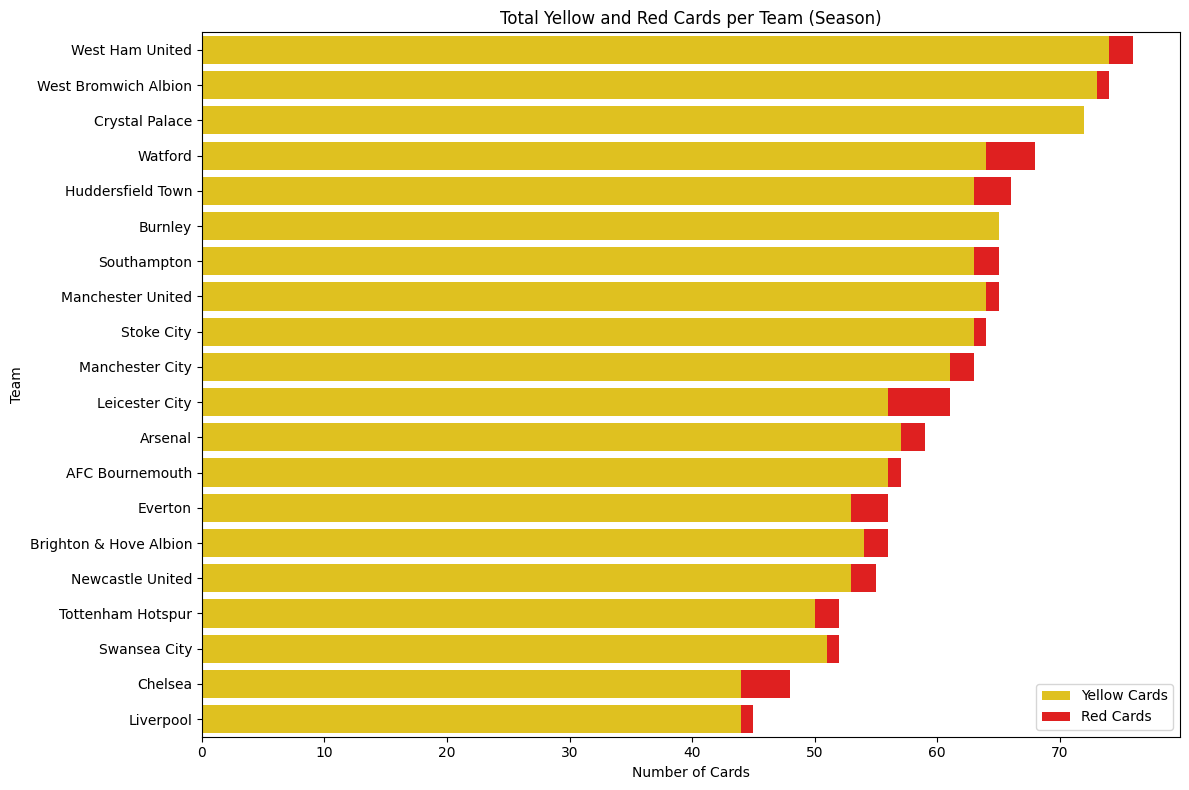

In [ ]:
team_cards_for_plot = merged_team_season_totals.copy()
team_cards_for_plot['total_cards'] = team_cards_for_plot['yellow_cards'] + team_cards_for_plot['red_cards']
team_cards_for_plot = team_cards_for_plot.sort_values(by='total_cards', ascending=False)

plt.figure(figsize=(12, 8))

# Plot yellow cards
sns.barplot(x='yellow_cards', y='name', data=team_cards_for_plot, color='gold', label='Yellow Cards')

# Plot red cards a coté des yellow cards
sns.barplot(x='red_cards', y='name', data=team_cards_for_plot, color='red', left=team_cards_for_plot['yellow_cards'], label='Red Cards')

plt.xlabel('Number of Cards')
plt.ylabel('Team')
plt.title('Total Yellow and Red Cards per Team (Season)')
plt.legend()
plt.tight_layout()
plt.show()

Mise en relation avec le nombre de défaites de chaque équipe.

Text(0.5, 1.0, 'Nombre de defaites par équipe')

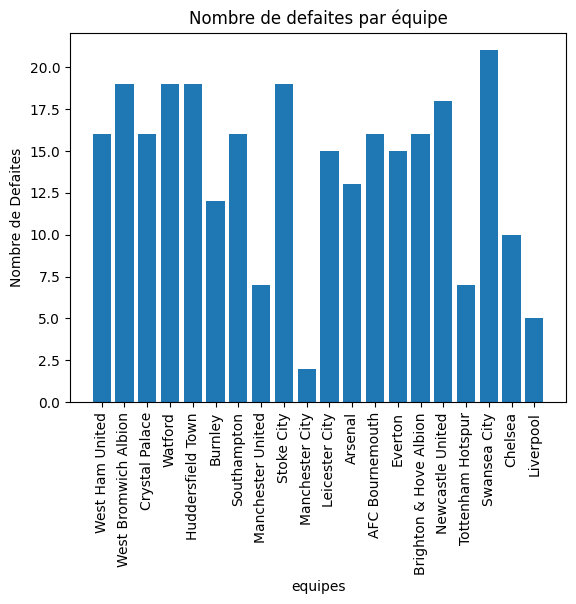

In [ ]:
#nombre de défaites par équipe
defeats_per_team = {}

for team_id in teams_df['wyId']:
    defeats_per_team[team_id] = 0

for index, row in df.iterrows():
    teams = row["teamsData"]
    home_team_id = None
    away_team_id = None
    home_ft_score = 0
    away_ft_score = 0

    for team_id_str, team_data in teams.items():
        if team_data['side'] == 'home':
            home_team_id = int(team_id_str)
            home_ft_score = team_data['score']
        else:
            away_team_id = int(team_id_str)
            away_ft_score = team_data['score']

    if home_ft_score > away_ft_score:

        if away_team_id in defeats_per_team:
            defeats_per_team[away_team_id] += 1
    elif away_ft_score > home_ft_score:

        if home_team_id in defeats_per_team:
            defeats_per_team[home_team_id] += 1



defeats_df = pd.DataFrame(list(defeats_per_team.items()), columns=['team_id', 'defeats'])


defeats_with_names_df = defeats_df.merge(
    teams_df[['wyId', 'name']],
    left_on='team_id',
    right_on='wyId',
    how='left'
).drop(columns=['wyId'])



combined_stats_df = team_cards_for_plot.merge(
    defeats_with_names_df[['name', 'defeats']],
    on='name',
    how='left'
)

plt.figure()
plt.bar(combined_stats_df['name'],combined_stats_df['defeats'])
plt.xticks( rotation = 90)
plt.xlabel('equipes')
plt.ylabel('Nombre de Defaites')
plt.title('Nombre de defaites par équipe')

In [ ]:
#nuage de points entre le nombre de defaites et le nombre de cartons par equipe
fig = px.scatter(
    combined_stats_df,
    x='total_cards',
    y='defeats',
    text='name',
    color='name',
    title='Total Cartons vs. Total Defaites par équipe',
    labels={
        'total_cards': 'Total Cards (Yellow + Red)',
        'defeats': 'Total Defeats'
    },
    height=600
)

fig.update_traces(textposition='top center')
fig.update_layout(
    xaxis_title='Total Cartons (Jaune + Rouge)',
    yaxis_title='Total Défaites',
    hovermode='closest'
)

fig.show()

On voit qu'en générale les équipes qui perdent le plus sont ceux qui prennent le plus de cartons (exemple: WestHam United,West Bromwich) et les équipes qui perdent le moins ne prennent pas beaucoup de cartons (exemple: Liverpool).

### **3.Style de jeu et Joueurs decisifs**

Pour quelques des meilleurs équipes du classement de fin de saison ,on va chercher les joueurs les plus influents dont la presence ou l'abcense influence fortement l'issue d'un match.Mais aussi nous allons nous intéresser aux profils de ces joueurs.

 Classement en fin saison

In [ ]:
# On Identifie tous les teamId presents dans df
team_ids_in_df = set()
for _, row in df.iterrows():
    for team_id_str in row["teamsData"].keys():
        team_ids_in_df.add(int(team_id_str))

# Initialison des points par equipe
pointsParEquipe = {team_id: 0 for team_id in team_ids_in_df}

# Calcul des points pour chaque match
for index, row in df.iterrows():
    teams = row["teamsData"]
    home_team_id = None
    away_team_id = None

    for team_id_str, team_data in teams.items():
        team_id = int(team_id_str)
        if team_data['side'] == 'home':
            home_team_id = team_id
        else:
            away_team_id = team_id

    # Assignation des points selon l'issue du match
    if row['winner'] == home_team_id:

        pointsParEquipe[home_team_id] += 3
    elif row['winner'] == away_team_id:

        pointsParEquipe[away_team_id] += 3
    else:
        # match nul
        pointsParEquipe[home_team_id] += 1
        pointsParEquipe[away_team_id] += 1


pointsParEquipe_df = pd.DataFrame(list(pointsParEquipe.items()), columns=['team_id', 'points'])


final_ranking_df = pointsParEquipe_df.merge(
    teams_df[['wyId', 'name']],
    left_on='team_id',
    right_on='wyId',
    how='left'
).drop(columns=['wyId'])


final_ranking_df = final_ranking_df.sort_values(by='points', ascending=False).reset_index(drop=True)

final_ranking_df


,team_id,points,name
0,1625,100,Manchester City
1,1611,81,Manchester United
2,1624,77,Tottenham Hotspur
3,1612,75,Liverpool
4,1610,70,Chelsea
5,1609,63,Arsenal
6,1646,54,Burnley
7,1623,48,Everton
8,1631,47,Leicester City
9,1628,44,Crystal Palace


On voit que Manchester City a largement dominé ses concurrents au titre de champion avec 19 points de plus sur le deuxieme ,Manchester United et 23 points de plus sur le troisieme à savoir Tottenham Hotspurs.
Mais comment Manchester City a pu exercer une telle domition sur championnat sur cette saison?

Qui sont leurs joueurs clés?

Pour répondre à cela nous allons passer par 3 étapes:

*   D'abord extraire les matchs de Man city ainsi que leurs joueurs ayant participé à ses matchs,

*   Ensuite identifier les résultats des matchs,


*   Et enfin calculer les pourcentages de victoires en cas de présence ou d'abcence de chaque joueur.


In [ ]:
# Step 1
man_city_id = teams_df[teams_df['name'] == 'Manchester City']['wyId'].iloc[0]    # Pour obtenir l'id de Man City
print(f"ID de Manchester City: {man_city_id}")

man_city_matches = []       # Les matchs de Man city

for index, row in df.iterrows():
    teams_data = row['teamsData']
    team_ids_in_match = [int(team_id) for team_id in teams_data.keys()]

    if man_city_id in team_ids_in_match:
        man_city_matches.append(row)

man_city_matches_df = pd.DataFrame(man_city_matches)



man_city_player_presence_data = []      # Extraction des joueurs titulaires et remplacants des matchs de Man City

for index, row in man_city_matches_df.iterrows():
    match_id = row['wyId']
    teams_data = row['teamsData']

    man_city_team_data = None
    for team_id_str, team_data in teams_data.items():
        if int(team_id_str) == man_city_id:
            man_city_team_data = team_data
            break                                 # On ne s'interesse qu'à notre équipe
    if man_city_team_data:
        # On vérifie qu'on est bien sur notre équipe
        lineup_players = man_city_team_data['formation'].get('lineup', [])  #titulaires

        substitutions_list = man_city_team_data['formation'].get('substitutions', [])   #joueurs rentrés
        sub_in_players_data = []
        for sub_event in substitutions_list:
            if 'playerIn' in sub_event:
                sub_in_players_data.append({'playerId': sub_event['playerIn']})

        all_players_in_match = lineup_players + sub_in_players_data

        for player_data in all_players_in_match:
            player_id = player_data['playerId']
            man_city_player_presence_data.append({
                'match_id': match_id,
                'player_id': player_id,
                'team_id': man_city_id
            })

man_city_player_presence_df = pd.DataFrame(man_city_player_presence_data)

man_city_player_presence_df = man_city_player_presence_df.merge(
    players_df[['wyId', 'shortName']],
    left_on='player_id',
    right_on='wyId',
    how='left'
).drop(columns=['wyId'])

print("Players presence (appercu du dataframe)")
display(man_city_player_presence_df.head()) # Appercu
print("\n \n")


# Step 2
man_city_results = []

for index, row in man_city_matches_df.iterrows():
    if row['winner'] == man_city_id:
        man_city_results.append('Win')
    elif row['winner'] == 0:
        man_city_results.append('Draw')
    else:
        man_city_results.append('Loss')

print("Resultats des matchs :")
man_city_matches_df['man_city_result'] = man_city_results #appercu
display(man_city_matches_df['man_city_result'].head())
print("\n \n")


# Step 3
unique_man_city_players = man_city_player_presence_df[['player_id', 'shortName']].drop_duplicates()  # on supprime les elements repetetifs

player_impact_data = []

for index, player_row in unique_man_city_players.iterrows(): # pour chaque joueur
    player_id = player_row['player_id']
    player_name = player_row['shortName']

    # Matchs ou le joueur est présent
    matches_present_ids = man_city_player_presence_df[man_city_player_presence_df['player_id'] == player_id]['match_id'].unique() # id des matchs
    matches_present_df = man_city_matches_df[man_city_matches_df['wyId'].isin(matches_present_ids)]  # creation dataframe pour ces matchs

    total_matches_present = len(matches_present_df)
    wins_present = len(matches_present_df[matches_present_df['man_city_result'] == 'Win'])
    if total_matches_present > 0 :
      win_rate_present = (wins_present / total_matches_present) * 100   #calcul de la win rate
    else :
      win_rate_present = 0

    # Matchs ou le joueur est absent
    all_man_city_match_ids = man_city_matches_df['wyId'].unique()
    matches_absent_ids = np.setdiff1d(all_man_city_match_ids, matches_present_ids)     # id des matchs
    matches_absent_df = man_city_matches_df[man_city_matches_df['wyId'].isin(matches_absent_ids)]   # dataframe pour ces matchs

    total_matches_absent = len(matches_absent_df)
    wins_absent = len(matches_absent_df[matches_absent_df['man_city_result'] == 'Win'])
    if total_matches_absent > 0 :
      win_rate_absent = (wins_absent / total_matches_absent) * 100
    else :
      win_rate_absent = 0

    # Calcul de la différence
    win_rate_difference = win_rate_present - win_rate_absent

    player_impact_data.append({
        'player_id': player_id,
        'player_name': player_name,
        'win_rate_present': win_rate_present,
        'win_rate_absent': win_rate_absent,
        'win_rate_difference': win_rate_difference,
        'total_matches_present': total_matches_present,
        'total_matches_absent': total_matches_absent
    })

player_impact_df = pd.DataFrame(player_impact_data)

# TOP 5 des joueurs les + influents
print("TOP 5 des joueurs les + influents avec au moins 30 matchs :")
display(player_impact_df[player_impact_df['total_matches_present']>=28].sort_values(by='win_rate_difference', ascending=False))




ID de Manchester City: 1625
Players presence (appercu du dataframe)


,match_id,player_id,team_id,shortName
0,2500095,8464,1625,F. Delph
1,2500095,265673,1625,Bernardo Silva
2,2500095,14808,1625,\u0130. G\u00fcndo\u011fan
3,2500095,9380,1625,J. Stones
4,2500095,245364,1625,L. San\u00e9



 

Resultats des matchs :


,man_city_result
6,Win
11,Win
18,Draw
28,Win
37,Win



 

TOP 5 des joueurs les + influents avec au moins 30 matchs :


,player_id,player_name,win_rate_present,win_rate_absent,win_rate_difference,total_matches_present,total_matches_absent
21,8317,David Silva,89.655172,66.666667,22.988506,29,9
11,340386,Gabriel Jesus,86.206897,77.777778,8.429119,29,9
4,245364,L. San\u00e9,84.375000,83.333333,1.041667,32,6
20,8277,K. Walker,84.375000,83.333333,1.041667,32,6
2,14808,\u0130. G\u00fcndo\u011fan,83.333333,87.500000,-4.166667,30,8
9,38021,K. De Bruyne,83.783784,100.000000,-16.216216,37,1
22,71654,Ederson,83.333333,100.000000,-16.666667,36,2
1,265673,Bernardo Silva,82.857143,100.000000,-17.142857,35,3
10,105339,Fernandinho,82.352941,100.000000,-17.647059,34,4
19,70086,N. Otamendi,82.352941,100.000000,-17.647059,34,4


Cette analyse nous montre que :

*   Plusieurs joueurs ont une pourcentage de victoire élevé en cas de présence mais celui avec le plus de matchs joués est Kevin De Bruyne avec 37 matchs/38 et 83.7% de victoires s'il est là.On peut donc conclure que c'est le joueur clé de cette équipe.Mention honorable aussi à Kyle walker et Leroy Sané.
*   Elle nous montre aussi que le succes de cette équipe repose sur un fort collectif car il est trés difficile de sortir des individualités,les pourcentages de victoires en cas de presence ou d'abcence de plusieurs joueurs etant tres proches les uns des autres.



Faisons la meme chose mais avec Liverpool.

In [ ]:
teams_df[teams_df['name']=='Liverpool']

,city,name,wyId,officialName,area,type
77,Liverpool,Liverpool,1612,Liverpool FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club


In [ ]:
# Step 1
liverpool_id = teams_df[teams_df['name'] == 'Liverpool']['wyId'].iloc[0]    # Pour obtenir l'id de liverpool
print(f"ID de Liverpool: {liverpool_id}")

liverpool_matches = []       # Les matchs de liverpool
for index, row in df.iterrows():
    teams_data = row['teamsData']
    team_ids_in_match = [int(team_id) for team_id in teams_data.keys()]

    if liverpool_id in team_ids_in_match:
        liverpool_matches.append(row)

liverpool_matches_df = pd.DataFrame(liverpool_matches)



liverpool_player_presence_data = []      # Extraction des joueurs titulaires et remplacants des matchs

for index, row in liverpool_matches_df.iterrows():
    match_id = row['wyId']
    teams_data = row['teamsData']

    liverpool_team_data = None
    for team_id_str, team_data in teams_data.items():
        if int(team_id_str) == liverpool_id:
            liverpool_team_data = team_data
            break                                 # On ne s'interesse qu'à notre équipe
    if liverpool_team_data:
        # On vérifie qu'on est bien sur notre équipe
        lineup_players = liverpool_team_data['formation'].get('lineup', [])  #titulaires

        substitutions_list = liverpool_team_data['formation'].get('substitutions', [])   #joueurs rentrés
        sub_in_players_data = []
        for sub_event in substitutions_list:
            if 'playerIn' in sub_event:
                sub_in_players_data.append({'playerId': sub_event['playerIn']})

        all_players_in_match = lineup_players + sub_in_players_data

        for player_data in all_players_in_match:
            player_id = player_data['playerId']
            liverpool_player_presence_data.append({
                'match_id': match_id,
                'player_id': player_id,
                'team_id': liverpool_id
            })

liverpool_player_presence_df = pd.DataFrame(liverpool_player_presence_data)

liverpool_player_presence_df = liverpool_player_presence_df.merge(
    players_df[['wyId', 'shortName']],
    left_on='player_id',
    right_on='wyId',
    how='left'
).drop(columns=['wyId'])

print("Players presence (appercu du dataframe)")
display(liverpool_player_presence_df.head()) # Appercu
print("\n \n")


# Step 2
liverpool_results = []

for index, row in liverpool_matches_df.iterrows():
    if row['winner'] == liverpool_id:
        liverpool_results.append('Win')
    elif row['winner'] == 0:
        liverpool_results.append('Draw')
    else:
        liverpool_results.append('Loss')

print("Resultats des matchs :")
liverpool_matches_df['liverpool_result'] = liverpool_results #appercu
display(liverpool_matches_df['liverpool_result'].head())
print("\n \n")


# Step 3
unique_liverpool_players = liverpool_player_presence_df[['player_id', 'shortName']].drop_duplicates()  # on supprime les elements repetetifs

player_impact_data = []

for index, player_row in unique_liverpool_players.iterrows(): # pour chaque joueur
    player_id = player_row['player_id']
    player_name = player_row['shortName']

    # Matchs ou le joueur est présent
    matches_present_ids = liverpool_player_presence_df[liverpool_player_presence_df['player_id'] == player_id]['match_id'].unique() # id des matchs
    matches_present_df = liverpool_matches_df[liverpool_matches_df['wyId'].isin(matches_present_ids)]  # creation dataframe pour ces matchs en verifiant si l'id dans matches_presence_ids

    total_matches_present = len(matches_present_df)
    wins_present = len(matches_present_df[matches_present_df['liverpool_result'] == 'Win'])
    if total_matches_present > 0 :
      win_rate_present = (wins_present / total_matches_present) * 100   #calcul de la win rate
    else :
      win_rate_present = 0

    # Matchs ou le joueur est absent
    all_liverpool_match_ids = liverpool_matches_df['wyId'].unique()
    matches_absent_ids = np.setdiff1d(all_liverpool_match_ids, matches_present_ids)     # id des matchs
    matches_absent_df = liverpool_matches_df[liverpool_matches_df['wyId'].isin(matches_absent_ids)]   # dataframe pour ces matchs

    total_matches_absent = len(matches_absent_df)
    wins_absent = len(matches_absent_df[matches_absent_df['liverpool_result'] == 'Win'])
    if total_matches_absent > 0 :
      win_rate_absent = (wins_absent / total_matches_absent) * 100
    else :
      win_rate_absent = 0

    # Calcul de la différence
    win_rate_difference = win_rate_present - win_rate_absent

    player_impact_data.append({
        'player_id': player_id,
        'player_name': player_name,
        'win_rate_present': win_rate_present,
        'win_rate_absent': win_rate_absent,
        'win_rate_difference': win_rate_difference,
        'total_matches_present': total_matches_present,
        'total_matches_absent': total_matches_absent
    })

player_impact_df = pd.DataFrame(player_impact_data)

# TOP 5 des joueurs les + influents
print("TOP 5 des joueurs les + influents avec au moins 28 matchs :")
display(player_impact_df[player_impact_df['total_matches_present']>=28].sort_values(by='win_rate_difference', ascending=False))


ID de Liverpool: 1612
Players presence (appercu du dataframe)


,match_id,player_id,team_id,shortName
0,2500092,25747,1612,S. Man\u00e9
1,2500092,15808,1612,Roberto Firmino
2,2500092,120353,1612,Mohamed Salah
3,2500092,25393,1612,D. Lovren
4,2500092,286831,1612,D. Solanke



 

Resultats des matchs :


,liverpool_result
3,Win
17,Loss
35,Draw
41,Draw
50,Win



 

TOP 5 des joueurs les + influents avec au moins 28 matchs :


,player_id,player_name,win_rate_present,win_rate_absent,win_rate_difference,total_matches_present,total_matches_absent
1,15808,Roberto Firmino,56.756757,0.000000,56.756757,37,1
15,8319,J. Milner,59.375000,33.333333,26.041667,32,6
7,116,G. Wijnaldum,57.575758,40.000000,17.575758,33,5
3,25393,D. Lovren,57.142857,50.000000,7.142857,28,10
19,7868,A. Oxlade-Chamberlain,56.250000,50.000000,6.250000,32,6
2,120353,Mohamed Salah,55.555556,50.000000,5.555556,36,2
0,25747,S. Man\u00e9,55.172414,55.555556,-0.383142,29,9


Analyse :    
* On constate que le joueur le plus important en prenant compte aussi du nombre de matchs joués est Roberto Firmino avec 56.7% de victoires remportées lorsqu'il est présent et il n'a manqué qu'un seul match de la saison.
* Mention honorable aussi à Mo Salah , Sadio Mané et G. Wijnaldum dont l'influence est aussi tres grande.

Maintenant nous allons étudions le Profil de quelques top joueurs du championnats: K.D.Bruyne et Firmino à partir de leurs statistiques au cours de la saison:


**Carte des passes intelligentes de K.D.Bruyne.**

In [ ]:
kdb_player_id = players_df[players_df['shortName'] == 'K. De Bruyne']['wyId'].iloc[0]

kdb_passes_df = events_df[(events_df['playerId'] == kdb_player_id) & (events_df['subEventName'] == 'Smart pass')].copy()

x_start = []
y_start = []
x_end = []
y_end = []

# Preparation des coordonnées pour les passes
for index, row in kdb_passes_df.iterrows():
    if len(row['positions']) >= 2:
        start_pos = row['positions'][0]
        end_pos = row['positions'][-1]
        x_start.append(start_pos['x'])
        y_start.append(start_pos['y'])
        x_end.append(end_pos['x'])
        y_end.append(end_pos['y'])
    else:
        x_start.append(None)
        y_start.append(None)
        x_end.append(None)
        y_end.append(None)

kdb_passes_df['x_start'] = x_start
kdb_passes_df['y_start'] = y_start
kdb_passes_df['x_end'] = x_end
kdb_passes_df['y_end'] = y_end

In [ ]:
# creation du terrain de football
field_shapes = [
    # lignes de touche
    dict(type='rect', xref='x', yref='y', x0=0, y0=0, x1=100, y1=100, line=dict(color='white', width=2)),
    # ligne du milieu
    dict(type='line', xref='x', yref='y', x0=50, y0=0, x1=50, y1=100, line=dict(color='white', width=2)),
    # cercle centrale
    dict(type='circle', xref='x', yref='y', x0=40, y0=40, x1=60, y1=60, line=dict(color='white', width=2)),
    # surface de rep gauche
    dict(type='rect', xref='x', yref='y', x0=0, y0=21.1, x1=16.5, y1=78.9, line=dict(color='white', width=2)),
    # surface de rep droite
    dict(type='rect', xref='x', yref='y', x0=100-16.5, y0=21.1, x1=100, y1=78.9, line=dict(color='white', width=2)),
    # cage gauche
    dict(type='rect', xref='x', yref='y', x0=0, y0=36.7, x1=5.5, y1=63.3, line=dict(color='white', width=2)),
    # cage droite
    dict(type='rect', xref='x', yref='y', x0=100-5.5, y0=36.7, x1=100, y1=63.3, line=dict(color='white', width=2)),
    # cages
    dict(type='rect', xref='x', yref='y', x0=-1, y0=44, x1=0, y1=56, line=dict(color='white', width=2), fillcolor='white'),
    dict(type='rect', xref='x', yref='y', x0=100, y0=44, x1=101, y1=56, line=dict(color='white', width=2), fillcolor='white')
]

# list des coordonnées de passes
plot_x_coords = []
plot_y_coords = []
for i in range(len(kdb_passes_df)):
    plot_x_coords.append(kdb_passes_df['x_start'].iloc[i])
    plot_y_coords.append(kdb_passes_df['y_start'].iloc[i])
    plot_x_coords.append(kdb_passes_df['x_end'].iloc[i])
    plot_y_coords.append(kdb_passes_df['y_end'].iloc[i])
    plot_x_coords.append(None) # Separator for new line
    plot_y_coords.append(None) # Separator for new line

fig = go.Figure()

# lignes pour les passes
fig.add_trace(
    go.Scatter(
        x=plot_x_coords,
        y=plot_y_coords,
        mode='lines',
        line=dict(color='yellow', width=1),
        name='De Bruyne Smart Passes',
        hoverinfo='skip' # Optional: disable hover for individual segments if too many
    )
)

# ajout de fleche pour la direction
annotations = []
for index, row in kdb_passes_df.iterrows():
    if pd.notna(row['x_start']) and pd.notna(row['y_start']) and pd.notna(row['x_end']) and pd.notna(row['y_end']):
        annotations.append(
            go.layout.Annotation(
                x=row['x_end'], y=row['y_end'],
                ax=row['x_start'], ay=row['y_start'],
                xref='x', yref='y', axref='x', ayref='y',
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=2,
                arrowcolor='yellow'
            )
        )

fig.update_layout(
    title_text="Kevin De Bruyne's Smart Passes (Season) - Manchester City",
    xaxis=dict(
        range=[0, 100],
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        title=''
    ),
    yaxis=dict(
        range=[0, 100],
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        title=''
    ),
    shapes=field_shapes,
    plot_bgcolor='green',
    paper_bgcolor='lightgrey',
    height=600,
    width=800,
    showlegend=False,
    annotations=annotations
)

fig.show()

**Analyse**:

On voit que De Bruyne a effectué beaucoup de passes intelligentes dans la surface adverse et plus particulierement dans le dernier tiers du terrain.C'est donc un créateur d'occasions pour ces coéquipiers .Il organise le jeu offensif de son équipe et délivre certainement beaucoup de passes décisives et de passes menant à des buts.Ceci peut expliquer son importance .



---



**Zones de touchée de balles de R.Firmino**

In [ ]:
firmino_player_id = players_df[players_df['shortName'] == 'Roberto Firmino']['wyId'].iloc[0]

firmino_touches_df = events_df[
    (events_df['playerId'] == firmino_player_id) &
    (events_df['eventName'] == 'Others on the ball') &
    (events_df['subEventName'] == 'Touch')
].copy()

x_touches = []
y_touches = []

for index, row in firmino_touches_df.iterrows():
    if len(row['positions']) > 0:
        # Utilisons les touches qui nous intéressent dans le dataframe events_df
        touch_pos = row['positions'][0]
        x_touches.append(touch_pos['x'])
        y_touches.append(touch_pos['y'])

firmino_touches_df['x_touch'] = x_touches
firmino_touches_df['y_touch'] = y_touches

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Plot de definition du terrain de foot
field_shapes = [
    dict(type='rect', xref='x', yref='y', x0=0, y0=0, x1=100, y1=100, line=dict(color='white', width=2)),
    dict(type='line', xref='x', yref='y', x0=50, y0=0, x1=50, y1=100, line=dict(color='white', width=2)),
    dict(type='circle', xref='x', yref='y', x0=40, y0=40, x1=60, y1=60, line=dict(color='white', width=2)),
    dict(type='rect', xref='x', yref='y', x0=0, y0=21.1, x1=16.5, y1=78.9, line=dict(color='white', width=2)),
    dict(type='rect', xref='x', yref='y', x0=100-16.5, y0=21.1, x1=100, y1=78.9, line=dict(color='white', width=2)),
    dict(type='rect', xref='x', yref='y', x0=0, y0=36.7, x1=5.5, y1=63.3, line=dict(color='white', width=2)),
    dict(type='rect', xref='x', yref='y', x0=100-5.5, y0=36.7, x1=100, y1=63.3, line=dict(color='white', width=2)),
    dict(type='rect', xref='x', yref='y', x0=-1, y0=44, x1=0, y1=56, line=dict(color='white', width=2), fillcolor='white'),
    dict(type='rect', xref='x', yref='y', x0=100, y0=44, x1=101, y1=56, line=dict(color='white', width=2), fillcolor='white')
]

# heatmap
# On utilise bins pour avoir une bonne resolution du heatmap sinon elle n'est pas pertinente
bins = dict(x=dict(start=0, end=100, size=5), y=dict(start=0, end=100, size=5))

fig_firmino_heatmap = go.Figure(go.Histogram2d(
    x=firmino_touches_df['x_touch'],
    y=firmino_touches_df['y_touch'],
    xbins=bins['x'],
    ybins=bins['y'],
    colorscale='Hot',
    zauto=True,
    hovertemplate='X: %{x}<br>Y: %{y}<br>Touches: %{z}<extra></extra>'  # indique le nombre de touchée sur la zone
))

fig_firmino_heatmap.update_layout(
    title_text="Roberto Firmino's Ball Touches Heatmap (Season) - Liverpool",
    xaxis=dict(
        range=[0, 100],
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        title=''
    ),
    yaxis=dict(
        range=[0, 100],
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        title=''
    ),
    shapes=field_shapes, # tracage du terrain
    plot_bgcolor='green',
    paper_bgcolor='lightgrey',
    height=600,
    width=800,
    showlegend=False
)

fig_firmino_heatmap.show()

**Analyse** :       

On voit que Firmino est actif sur tout la moitié de terrain adverse.Donc Malgres qu'il soit un attaquant ,il participe au jeu de son équipe et est aussi trés actif dans la surface adverse pour des buts ou des passes décisives.



---



## **III-  Modélisation**

Maintenant, nous allons créer un modele donnant les chances de victoire d'une équipe à son prochain match avec comme parametre : l'équipe joue à l'exterieur ou à domicile , et le nombre moyen de buts marqués et encaissés.

Nous utiliserons pour la prédiction un modele de regression logistique avec l'importation de la biblioteque sklearn des méthodes Logistique regression, train_test_split et accuracy_score.

Nous procéderons en plusieurs étapes:

In [ ]:
from sklearn.model_selection import train_test_split   # pour l'entrainement du modele
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score            # pour determiner sa precision


#CONSTRUISONS UN DATASET PAR ÉQUIPE / MATCH

rows = []

for _, row in df.iterrows():
    teams = row["teamsData"]
    scores = {t["teamId"]: t["score"] for t in teams.values()}

    for t in teams.values():
        team = t["teamId"]
        opponent = [x for x in scores.keys() if x != team][0]

        rows.append({
            "teamId": team,
            "is_home": 1 if t["side"] == "home" else 0,
            "goals_scored": t["score"],
            "goals_conceded": scores[opponent],
            "win": 1 if t["score"] > scores[opponent] else 0
        })

team_df = pd.DataFrame(rows)

# STATISTIQUES MOYENNES PAR ÉQUIPE

stats = (
    team_df
    .groupby("teamId")
    .agg(
        avg_scored=("goals_scored", "mean"),      # moyenne de buts marqués
        avg_conceded=("goals_conceded", "mean")   # |        |  |   concedés
    )
    .reset_index()
)

team_df = team_df.merge(stats, on="teamId")
#display(team_df.head())

#  VARIABLES POUR LE MODÈLE

X = team_df[["is_home", "avg_scored", "avg_conceded"]]
y = team_df["win"]

# ENTRAÎNEMENT DU MODÈLE

model = LogisticRegression()
model.fit(X, y)

#  PRÉDICTION D’UN PROCHAIN MATCH

# Exemple : Manchester City à domicile
team_id = 1625  # à remplacer par l'équipe voulue

team_stats = stats[stats["teamId"] == team_id].iloc[0]

next_match = pd.DataFrame([{
    "is_home": 1,  # 1 = domicile, 0 = extérieur
    "avg_scored": team_stats["avg_scored"],
    "avg_conceded": team_stats["avg_conceded"]
}])

proba = model.predict_proba(next_match)[0][1]

print(f"Probabilité de victoire : {proba:.2%}")


Probabilité de victoire : 87.35%


Précision de ce modele.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# entrainement
model_eval = LogisticRegression()
model_eval.fit(X_train, y_train)

y_pred = model_eval.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"La précision (accuracy) du modèle est de : {accuracy:.2%}")

La précision (accuracy) du modèle est de : 65.79%


Ce pourcentage est normale pour la precision d'un modele de prediction de matchs de football car ils sont difficiles à prévoir en général.

## Conclusion
En résumé , les facteurs menant à la victoire d'une équipe sont nombreuses.Il y a le nombre de buts marquées , l'avantage à domicile, la discipline , des joueurs d'exception ,un fort collectif.Cependant il est tres difficile de la prédire car le football est un sport à fort variance,les blessures des joueurs,les cartons sont imprévisibles et il peut y avoir des surprises dans les matchs .
